In [5]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('train.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [6]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071  

In [7]:
print(df['Survived'].value_counts())
print(df.groupby('Sex')['Survived'].mean())
print(df.groupby('Pclass')['Survived'].mean())

Survived
0    549
1    342
Name: count, dtype: int64
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


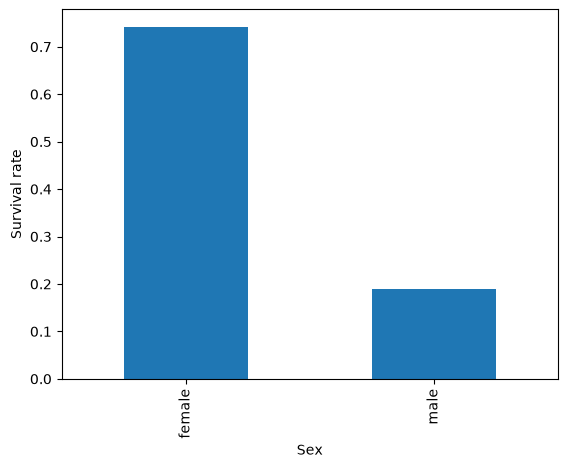

In [8]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.ylabel('Survival rate')
plt.show()

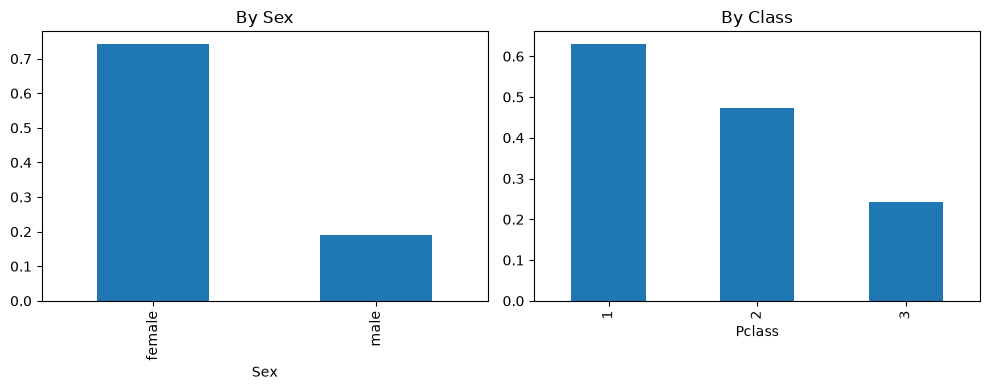

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0], title='By Sex')
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1], title='By Class')
plt.tight_layout()
plt.show()

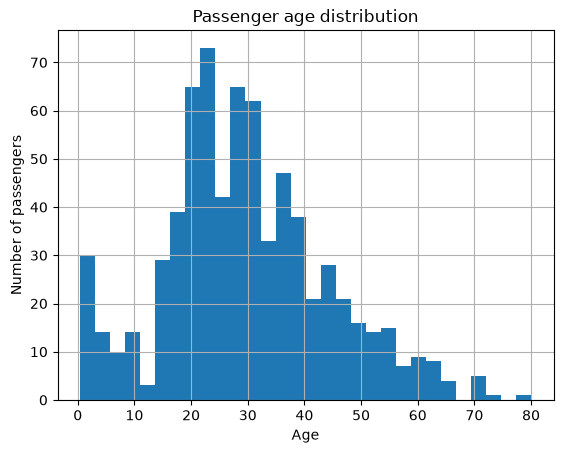

In [11]:
df['Age'].dropna().hist(bins=30) 
plt.xlabel('Age')
plt.ylabel('Number of passengers')
plt.title('Passenger age distribution')
plt.show()

Survival probability: 0.3838383838383838


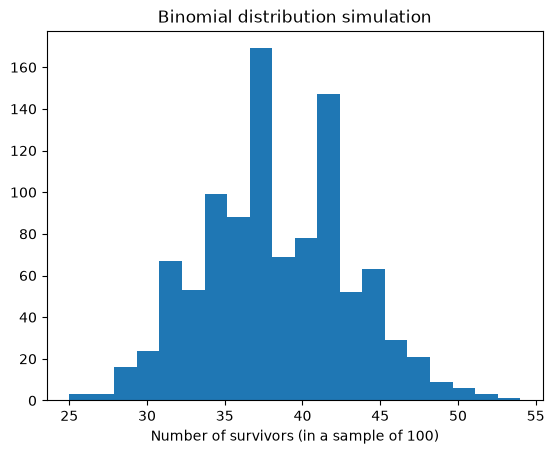

In [13]:
import numpy as np# P(Survived | Female) = P(Female | Survived) * P(Survived) / P(Female)

p_survived = df['Survived'].mean()
p_female = (df['Sex'] == 'female').mean()
p_female_given_survived = df[df['Survived']==1]['Sex'].eq('female').mean()

p_survived_given_female = (p_female_given_survived * p_survived) / p_female
print("Calculated via Bayes:", p_survived_given_female)
print("Calculated directly:", df[df['Sex']=='female']['Survived'].mean())

p_survive = df['Survived'].mean()
print("Survival probability:", p_survive)

# If we randomly picked 100 passengers, how many would survive? (simulation)
simulation = np.random.binomial(n=100, p=p_survive, size=1000)
plt.hist(simulation, bins=20)
plt.xlabel('Number of survivors (in a sample of 100)')
plt.title('Binomial distribution simulation')
plt.show()

In [14]:
# P(Survived | Female) = P(Female | Survived) * P(Survived) / P(Female)

p_survived = df['Survived'].mean()
p_female = (df['Sex'] == 'female').mean()
p_female_given_survived = df[df['Survived']==1]['Sex'].eq('female').mean()

p_survived_given_female = (p_female_given_survived * p_survived) / p_female
print("Calculated via Bayes:", p_survived_given_female)
print("Calculated directly:", df[df['Sex']=='female']['Survived'].mean())

Calculated via Bayes: 0.7420382165605095
Calculated directly: 0.7420382165605095


In [15]:
# For Age
print("Mean (expected value):", df['Age'].mean())
print("Variance:", df['Age'].var())
print("Standard deviation:", df['Age'].std())

Mean (expected value): 29.69911764705882
Variance: 211.01912474630802
Standard deviation: 14.526497332334042


In [16]:
ages = df['Age'].dropna()
mean_age = ages.mean()

variance_manual = ((ages - mean_age)**2).mean()
print("Manually calculated variance:", variance_manual)
print("pandas calculated:", ages.var(ddof=0))  # ddof=0: pandas uses a different formula by default, this matches it

Manually calculated variance: 210.72357975366617
pandas calculated: 210.72357975366617


In [17]:
print(df.groupby('Survived')['Age'].agg(['mean', 'std']))

               mean        std
Survived                      
0         30.626179  14.172110
1         28.343690  14.950952
